In [1]:
import string
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
# Function to see the first n entries of a dict
def head(dictionary, n):
    return dict(list(dictionary.items())[:n])

## Import Data

In [3]:
# import data 
url = "https://github.com/bozercavdar/kickstarter-project/releases/download/v1.0/kickstarter_data_OSF.csv"
local_path = "dataset.csv"

# UNCOMMENT THE LINE BELOW IF YOU DON'T HAVE THE DATASET IN THE LOCAL DIRECTORY
# df = pd.read_csv(url)
df = pd.read_csv(local_path)

In [4]:
# Filter only those required columns
selected_df = df[['uid', 'blurb', 'goal', 'state', 'usd_pledged', 'category']]
# Add column that states if a project is succesful or not
selected_df['success'] = selected_df['state'] == 'successful'
selected_df.head()

/tmp/ipykernel_1163/2469478530.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['success'] = selected_df['state'] == 'successful'


,uid,blurb,goal,state,usd_pledged,category,success
0,1,This project is designed to help protect the e...,2500.0,failed,0.0,Music,False
1,2,Help us built a sustainable studio & eliminate...,25000.0,failed,1.0,Technology,False
2,3,"""If I paint something, I don't want to have to...",5000.0,failed,5.0,Art,False
3,4,Our free app will allow you pool reservations ...,12000.0,failed,0.0,Food,False
4,5,Prohibition themed Gastro Pub and After Dark S...,20000.0,failed,0.0,Food,False


## EDA

In [5]:
selected_df['success'] = selected_df['state']=='successful'

# print some descriptive stats
print(f"Succesful rate: {selected_df['success'].mean()}")
print(f"Median goal: {selected_df['goal'].median()}")
print(f"Median raised: {selected_df['usd_pledged'].median()}")
print(f"# of category: {selected_df['category'].nunique()}")

Succesful rate: 0.5849306592836563
Median goal: 5000.0
Median raised: 1645.0
# of category: 16


/tmp/ipykernel_1163/2086693127.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['success'] = selected_df['state']=='successful'


In [27]:
# explore frequency
freq_df = pd.concat([selected_df['category'].value_counts()], axis=1)
freq_df['perc'] = freq_df['count'] / len(selected_df)
freq_df['perc'] = round(freq_df['perc'], 2)
freq_df

,count,perc
category,,
Music,22630,0.14
Film & Video,20756,0.13
Technology,16990,0.11
Publishing,16633,0.10
Art,16557,0.10
Food,12088,0.08
Games,9429,0.06
Fashion,8465,0.05
web,6088,0.04


In [ ]:
# Export median goal and mean success per category
pd.concat([selected_df.groupby('category').agg({'goal': 'median', 'success': 'mean'})], axis=1).to_excel("goal_df.xlsx")

In [19]:
# Add word count of each project's description
selected_df['word_count'] = selected_df['blurb'].apply(lambda blurb: len(blurb.split(" ")))

/tmp/ipykernel_54412/2880538111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['word_count'] = selected_df['blurb'].apply(lambda blurb: len(blurb.split(" ")))


In [20]:
# Average word number
print(f"Average word number: {selected_df['word_count'].mean()}")

Average word number: 18.916966132731694


In [21]:
# Function to create a dict with each words count 
def count_word(text:str, word_counter:dict):
    clear_text = text.translate(str.maketrans("", "", string.punctuation)).lower()
    clear_text = " ".join(clear_text.split())
    # print(clear_text)
    for word in clear_text.split(" "):
        count = word_counter.get(word)
        if count is None:
            word_counter[word] = 1
        else:
            word_counter[word] = count + 1


In [22]:
# Total word count 
total_word_dict = {}
for blurb in selected_df['blurb']:
    count_word(blurb, total_word_dict)

total_word_dict = dict(sorted(total_word_dict.items(), key=lambda item: item[1], reverse=True))
head(total_word_dict, 10)

{'the': 118112,
 'a': 116379,
 'and': 98671,
 'to': 90334,
 'of': 78257,
 'in': 45329,
 'for': 37171,
 'is': 36015,
 'with': 31088,
 'an': 20469}

In [23]:
# Remove the stop words from the dict
stop_words = ENGLISH_STOP_WORDS

filtered_word_dict = {w: c for w, c in total_word_dict.items() if w not in stop_words}
filtered_word_dict = dict(sorted(filtered_word_dict.items(), key=lambda item: item[1], reverse=True))
head(filtered_word_dict, 10)


{'help': 16516,
 'new': 15445,
 'book': 9186,
 'music': 8920,
 'album': 8272,
 'art': 8181,
 'world': 7921,
 'make': 7390,
 'film': 6807,
 'life': 6374}

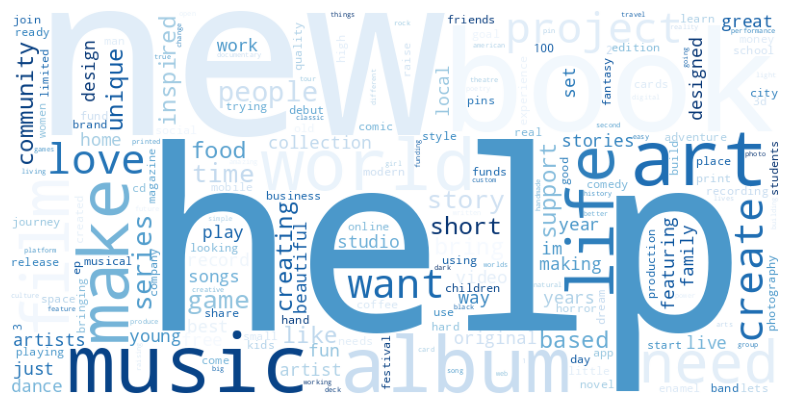

In [24]:
# Word cloud without the stop words
wordcloud = WordCloud(width=800, height=400, colormap="Blues", background_color="white").generate_from_frequencies(filtered_word_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

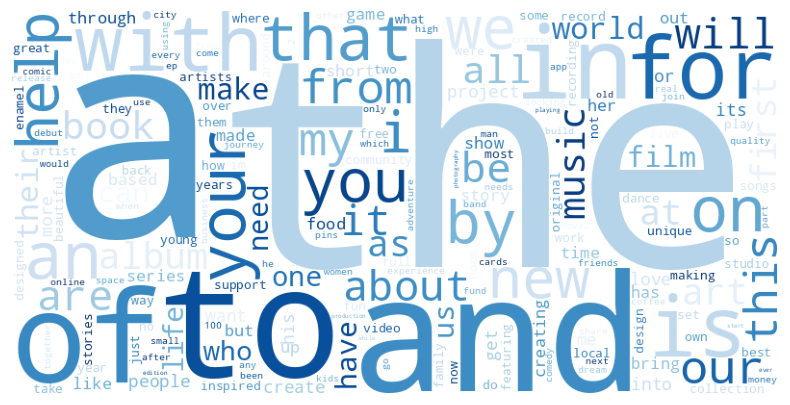

In [25]:
# word cloud including the stop words 
wordcloud = WordCloud(width=800, height=400, colormap="Blues", background_color="white").generate_from_frequencies(total_word_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()